In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import cmaps

In [2]:
shapefile_path = '/home/arif/Desktop/Python Lab/Assingment/Kolkata/Kolkata Shapefile/Kolkata.shp'
shapefile1 = gpd.read_file(shapefile_path)

In [3]:
shapefile1['geometry'].head()

0    POLYGON ((88.53308 22.53481, 88.53367 22.53481...
Name: geometry, dtype: geometry

In [4]:
mfdata_DIR='/home/arif/Desktop/Python Lab/Assingment/GPM_Data/gpm*'
df=xr.open_mfdataset(mfdata_DIR, parallel=True)
df

<xarray.Dataset> Size: 2MB
Dimensions:        (time: 48, lon: 85, lat: 106)
Coordinates:
  * lat            (lat) float32 424B 18.05 18.15 18.25 ... 28.35 28.45 28.55
  * lon            (lon) float32 340B 83.95 84.05 84.15 ... 92.15 92.25 92.35
  * time           (time) object 384B 2019-05-25 00:00:00 ... 2019-05-25 23:3...
Data variables:
    precipitation  (time, lon, lat) float32 2MB dask.array<chunksize=(1, 85, 106), meta=np.ndarray>
Attributes:
    FileHeader:                      DOI=10.5067/GPM/IMERG/3B-HH/07;\nDOIauth...
    FileInfo:                        DataFormatVersion=7e;\nTKCodeBuildVersio...
    history:                         2026-04-11 10:11:18 GMT hyrax-1.17.1 htt...
    history_json:                    [{"$schema":"https:\/\/harmony.earthdata...
    Grid.GridHeader:                 BinMethod=ARITHMETIC_MEAN;\nRegistration...
    Grid.fullnamepath:               /Grid
    DODS_EXTRA.Unlimited_Dimension:  time

In [5]:
#cropping data to required lat-lon extent
min_lon = 87.95
min_lat = 22.15
max_lon = 88.75
max_lat = 23.15

df1 = df.sel(lat=slice(min_lat,max_lat), lon=slice(min_lon,max_lon))

In [6]:
pricp=df1.precipitation
time=df1.time

In [7]:
lat=df1.lat
lon=df1.lon

In [8]:
time

<xarray.DataArray 'time' (time: 48)> Size: 384B
array([cftime.DatetimeJulian(2019, 5, 25, 0, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 0, 30, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 1, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 1, 30, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 2, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 2, 30, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 3, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 3, 30, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 4, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 4, 30, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 5, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 5, 30, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 6, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 6, 30, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 7, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 7, 30, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 8, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 8, 30, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 9, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 9, 30, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 10, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 10, 30, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 11, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 11, 30, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 12, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 12, 30, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 13, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 13, 30, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 14, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 14, 30, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 15, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 15, 30, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 16, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 16, 30, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 17, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 17, 30, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 18, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 18, 30, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 19, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 19, 30, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 20, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 20, 30, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 21, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 21, 30, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 22, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 22, 30, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 23, 0, 0, 0, has_year_zero=False),
       cftime.DatetimeJulian(2019, 5, 25, 23, 30, 0, 0, has_year_zero=False)],
      dtype=object)
Coordinates:
  * time     (time) object 384B 2019-05-25 00:00:00 ... 2019-05-25 23:30:00
Attributes:
    DimensionNames:  time
    Units:           seconds since 1980-01-06 00:00:00 UTC
    standard_name:   time
    LongName:      

In [9]:
pricp2=np.cumsum(pricp,axis=0)
pricp3=pricp2[45,:,:]
pricp3.shape

(9, 11)

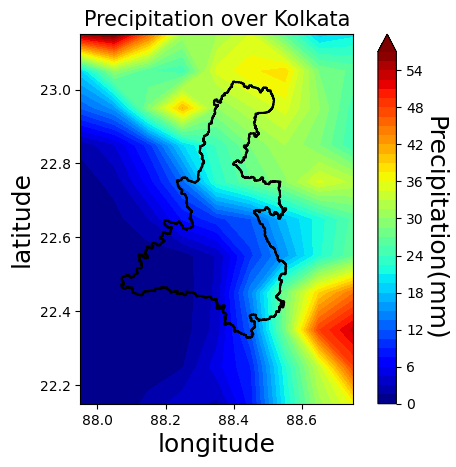

In [15]:
#### precipitation contour plot
ax=plt.contourf(lon,lat,pricp3.transpose(),levels=50,cmap='jet', extend='max')
cbar=plt.colorbar(ax)
# plt.clim(0,7)
cbar.set_label('Precipitation(mm)', fontsize=18,rotation=270, labelpad=16)
plt.xlabel('longitude', fontsize=18)
plt.ylabel('latitude', fontsize=18)
plt.title('Precipitation over Kolkata', fontsize=15)
ax=shapefile1.boundary.plot(ax=plt.gca(),color='k')
plt.savefig('/home/arif/Desktop/Python Lab/Assingment/Precipitation over Kolkata.png',dpi=300)
plt.show()